In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [3]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

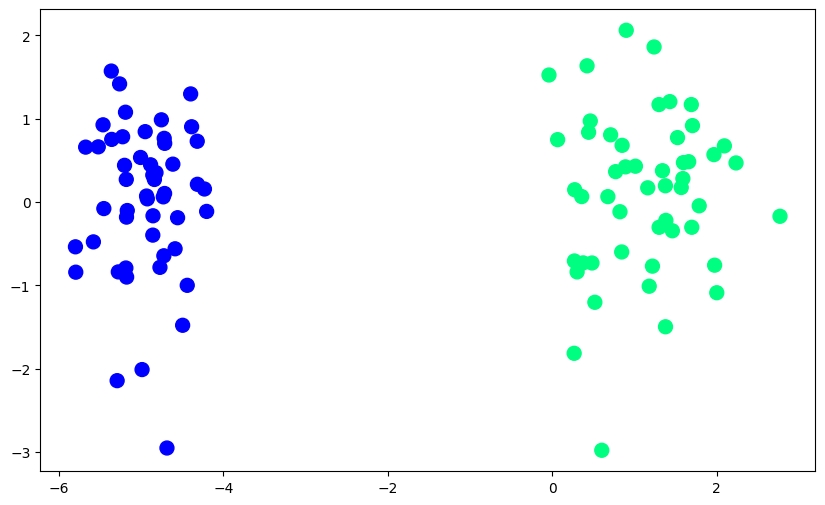

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

## Implementing step function for Logistic Regression

### Implementing the Preceptron Update Rule

In [5]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1) # adding bias term to the data in the starting of the data [x1,x2] -> [1, x1, x2]
    weights = np.ones(X.shape[1]) # initializing the weights
    lr = 0.1 # learning rate
    
    #  Defining The Number of Epoches
    for i in range(1000): # training for 1000 iterations
        j = np.random.randint(0,100) # randomly selecting a data point
        y_hat = step(np.dot(X[j],weights)) # calculating the predicted value
        weights = weights + lr*((y[j] - y_hat)*X[j]) # updating the weights using the perceptron update rule
        
    #  returing the intercept = w0 and the weights = [w1,w2]
    return weights[0] ,weights[1:]

### Defining the Exponential function

In [6]:
def step(z):
    return 1 if z>0 else 0

#### Intercept[w0] and Coefficient/ Weights [w1,w2,w3.....]

In [9]:
intercept_coef , weights_coef = perceptron(X,y)
print("intercept coefficient : ",intercept_coef,"weights coefficient : ",weights_coef)

intercept coefficient :  1.2000000000000002 weights coefficient :  [1.1204053  0.40381514]


#### generating the line equation using Intercept and Coefficient

In [10]:
# slop_of_line 
m = -weights_coef[0]/weights_coef[1]
print("slope of the line : ",m)
# intercept_of_line 
b = -intercept_coef/weights_coef[1]
print("intercept of the line : ",b)

slope of the line :  -2.7745500252190514
intercept of the line :  -2.9716568071029252


#### Creating the line using the Line Equation y = mx+b

In [11]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

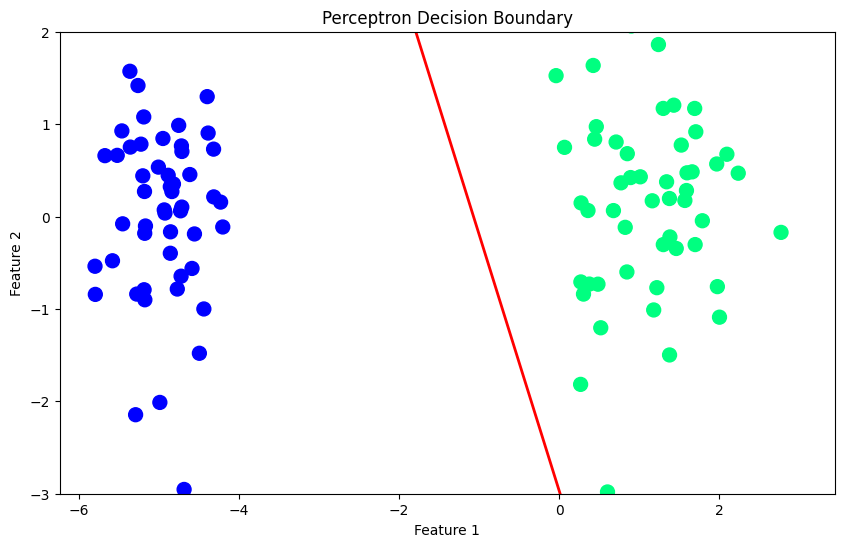

In [12]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter",s=100)
plt.ylim(-3,2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")
plt.show()

### Implementing the Logistic Regression using the Inbuilt Function

In [14]:
from sklearn.linear_model import LogisticRegression
logistic_regression_using_inbuilt_function = LogisticRegression()
logistic_regression_using_inbuilt_function.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Finding the coefficient and intercept using inbuilt logistic function

In [15]:
logistic_regression_using_inbuilt_function_coef = logistic_regression_using_inbuilt_function.coef_
logistic_regression_using_inbuilt_function_intercept = logistic_regression_using_inbuilt_function.intercept_
print("intercept coefficient : ",logistic_regression_using_inbuilt_function_intercept,"weights coefficient : ",logistic_regression_using_inbuilt_function_coef)

intercept coefficient :  [3.54700273] weights coefficient :  [[1.77255101 0.01190507]]


#### Creating the line Equation using the Coefficient and Intercept using the inbuilt logistic function

#### calculating the slope(m) and b (intercept)

In [16]:
m_logistic_inbuilt = -logistic_regression_using_inbuilt_function_coef[0][0]/logistic_regression_using_inbuilt_function_coef[0][1]
b_logistic_inbuilt = -logistic_regression_using_inbuilt_function_intercept/logistic_regression_using_inbuilt_function_coef[0][1]

#### Creating the line equation using slope and intercept the inbuilt logistic Regression function

In [18]:
x_input_logistic_inbuilt = np.linspace(-3,3,100)
y_input_logistic_inbuilt = m_logistic_inbuilt*x_input_logistic_inbuilt + b_logistic_inbuilt

(-3.0, 2.0)

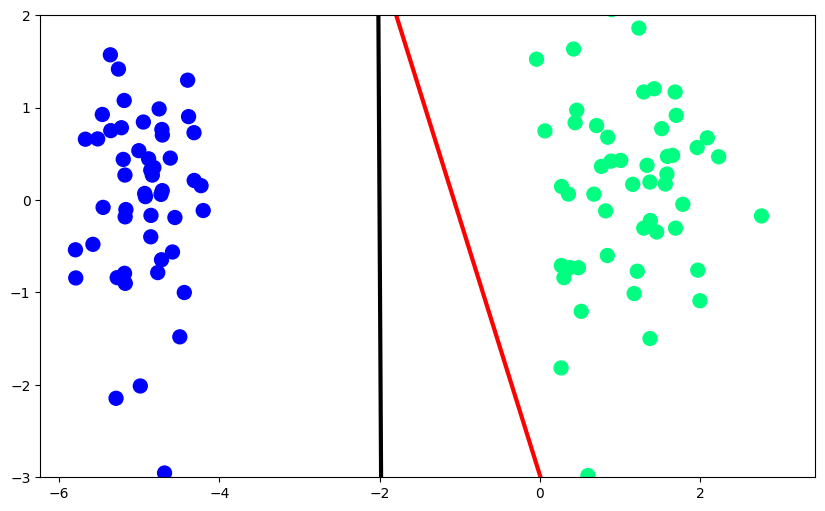

In [19]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input_logistic_inbuilt,y_input_logistic_inbuilt,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Implementing the Sigmoid function for logistic Regression

### Implementing the Preceptron Update Rule

In [20]:
def perceptron_custom_sigmoid(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [21]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [25]:
intercept_coef_custom_sigmoid ,weights_coef_custom_sigmoid = perceptron_custom_sigmoid(X,y)
print("intercept coefficient using custom sigmoid : ",intercept_coef_custom_sigmoid,"weights coefficient with Custom Sigmoid function : ",weights_coef_custom_sigmoid)

intercept coefficient using custom sigmoid :  2.5853473003189342 weights coefficient with Custom Sigmoid function :  [2.31581701 0.12704782]


In [26]:
m_custom_sigmoid = -weights_coef_custom_sigmoid[0]/weights_coef_custom_sigmoid[1]
b_custom_sigmoid = -intercept_coef_custom_sigmoid/weights_coef_custom_sigmoid[1]

In [29]:
X_input_custom_sigmoid = np.linspace(-3,3,100)
y_input_custom_sigmoid = m_custom_sigmoid*X_input_custom_sigmoid + b_custom_sigmoid

(-3.0, 2.0)

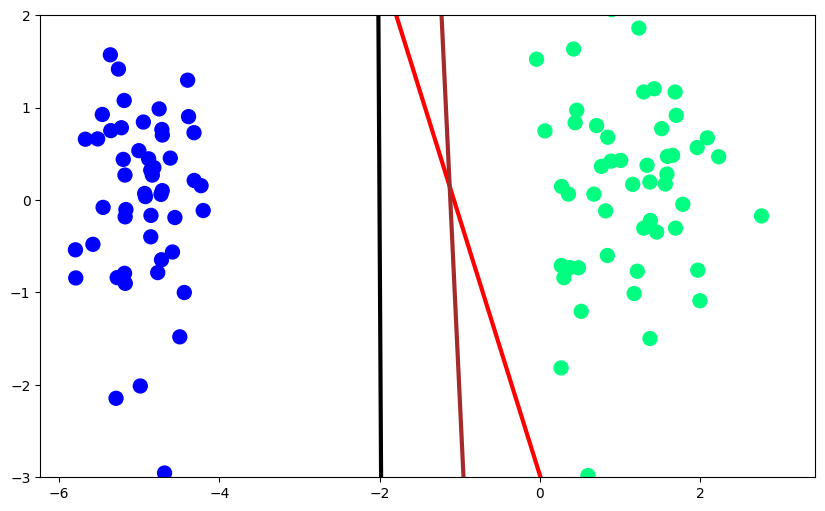

In [30]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input_logistic_inbuilt,y_input_logistic_inbuilt,color='black',linewidth=3)
plt.plot(X_input_custom_sigmoid,y_input_custom_sigmoid,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [31]:
def perceptron_animation_through_epoches(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [32]:
m,b = perceptron_animation_through_epoches(X,y)

In [33]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [35]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save("Preceptron Logistic Regression using Sigmoid.gif", writer=animation.PillowWriter(fps=10))
display(Image("Preceptron Logistic Regression using Sigmoid.gif"))

<IPython.core.display.Javascript object>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


NameError: name 'Image' is not defined